In [16]:
# 1) Environment / Imports (for debugging)
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np

import ansys.motorcad.core as pymotorcad

# Ensure repo root (folder containing 'tool/') is on sys.path
repo_root = pathlib.Path.cwd().resolve()
while not (repo_root / "tool").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print("repo_root:", repo_root)

# Import utilities extracted from the notebook
from tool.motorCAD.pyMCAD import (
    get_magnetic_data,
    get_magnetic_data_from_file,
    get_magnetic_timeseries_from_file,
    interactive_magnetic_plot,
    interactive_magnetic_quiver,
    mcad_default_export_dir,
    mcad_make_temp_txt_path,
    )

# Connect to Motor-CAD (uses existing instance by default)
mc = pymotorcad.MotorCAD(open_new_instance=False)

repo_root: D:\KangDH\Emlab_emach


In [17]:
# (Optional) Auto-reload local modules while you debug edits in tool/motorCAD/pyMCAD/*.py
try:
    %load_ext autoreload
    %autoreload 2
except Exception as e:
    print("autoreload not available:", e)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Magnetic FEA export & debug
이 노트북은 `tool/motorCAD/pyMCAD` 아래로 분리된 모듈을 import해서 실행/디버깅합니다.

In [18]:
# 2) Export + Parse (time series)
from pathlib import Path
from datetime import datetime

# Output file base name
out_dir = mcad_default_export_dir(mc)
base_filename = Path(out_dir) / "MagTransient.txt"
print("Output dir:", out_dir)
print("Base output file:", base_filename)

# Export settings
DO_EXPORT = True
first_step = 1
final_step = 10

def _unique_filename_if_exists(path: Path) -> Path:
    """If 'path' exists, return a new path with a timestamp suffix."""
    if not path.exists():
        return path
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return path.with_name(f"{path.stem}_{stamp}{path.suffix}")

# Choose filename
if DO_EXPORT:
    filename = _unique_filename_if_exists(base_filename)
    mc.save_fea_data(str(filename), int(first_step), int(final_step), "RegCode,Bx,By,A,J", "", ",")
    print("Exported (unique):", filename)
else:
    filename = base_filename
    print("Skipped export; using existing file:", filename)

# Parse all blocks in file
ts = get_magnetic_timeseries_from_file(filename, key="time_index", verbose=True)
print("Parsed steps:", ts.steps[:10], "..." if len(ts.steps) > 10 else "")

Output dir: E:\KDH\AdaptiveTemplate
Base output file: E:\KDH\AdaptiveTemplate\MagTransient.txt
Exported (unique): E:\KDH\AdaptiveTemplate\MagTransient_20260107_113853.txt
Parsed block key=0: elements=11330, nodes=5874
Parsed block key=1: elements=11330, nodes=5882
Parsed block key=2: elements=11330, nodes=5890
Parsed block key=3: elements=11330, nodes=5899
Parsed block key=4: elements=11330, nodes=5907
Parsed block key=5: elements=11330, nodes=5915
Parsed block key=6: elements=11330, nodes=5923
Parsed block key=7: elements=11330, nodes=5932
Parsed block key=8: elements=11330, nodes=5940
Parsed block key=9: elements=11330, nodes=5948
Parsed steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 


# Plots
아래 셀들은 `ts`(time series)를 대상으로 시각화합니다.

In [19]:
interactive_magnetic_plot(ts, quantity="b", s=2)

In [21]:
# Interactive quiver (step toggle)
# Tip: stride를 키우면 더 가볍게 볼 수 있습니다.
interactive_magnetic_quiver(ts, stride=1, scale=1, normalize=False)

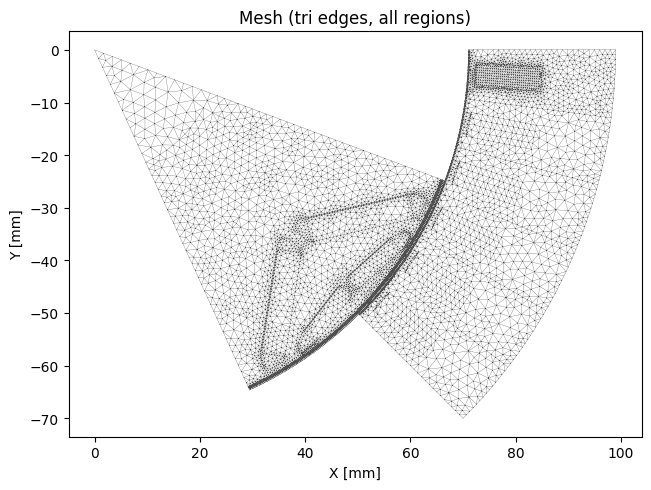

<Axes: title={'center': 'Mesh (tri edges, all regions)'}, xlabel='X [mm]', ylabel='Y [mm]'>

In [22]:
# Mesh plot example (tri edges)
ts.plot_mesh(step=ts.steps[0] if ts.steps else 0)